Intro to Python continued. Adapted from content created by James Murray.

# 8. Plotting with Matplotlib

Just as Python contains the library Numpy for numerical computation, it also contains a library called Matplotlib and a sublibrary called Pyplot for making plots to visualize data. We can import it as follows:

In [1]:
import matplotlib.pyplot as plt
import numpy as np

There are no exercises in this section, but it's still a good idea to look through the examples carefully and experiment with making some changes to test your understanding.

## Plotting lines and points

Let's start by plotting a line of evenly spaced x values and their corresponding y values.

(-1.0, 1.0)

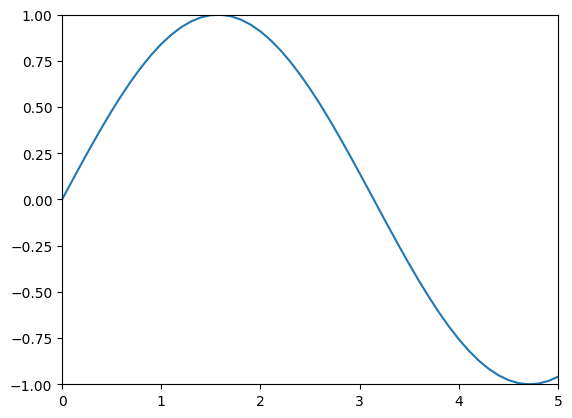

In [2]:
x = np.arange(0, 4*np.pi, 0.1) #Default steps at 1
y = np.sin(x)
plt.plot(x, y)
plt.xlim(0,5) #Applies to only the last plot created, sets x-axis length to the second argument
plt.ylim(-1,1)

Of course, it's always good practice to label our axes. Let's do this and also give the plot a title.

Text(0.5, 1.0, 'A sine wave')

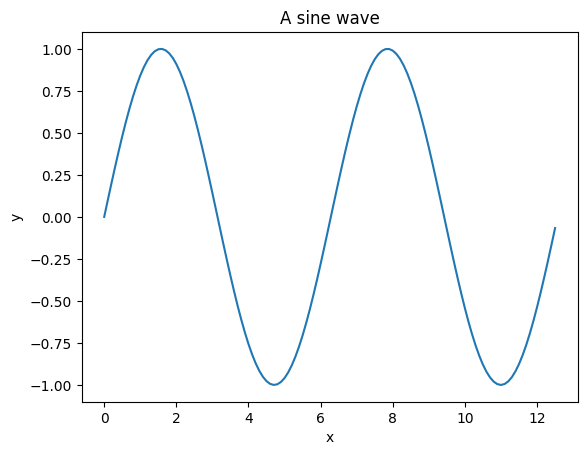

In [3]:
x = np.arange(0, 4*np.pi, 0.1)
y = np.sin(x)
plt.plot(x, y)
plt.xlabel('x')
plt.ylabel('y')
plt.title('A sine wave')

If we don't want all of the points to be connected with lines, we can include an extra argument in `plt.plot` that specifies what kind of point we want to be plotted.

Text(0.5, 1.0, 'A sine wave')

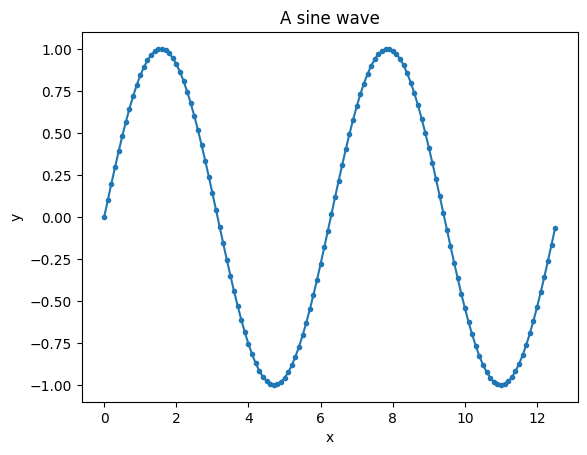

In [4]:
x = np.arange(0, 4*np.pi, 0.1)
y = np.sin(x)
plt.plot(x, y, '.-')  # also try replacing 'o' by 's' or '.' or '--'
plt.xlabel('x')
plt.ylabel('y')
plt.title('A sine wave')

We can also plot two curves in the same figure.

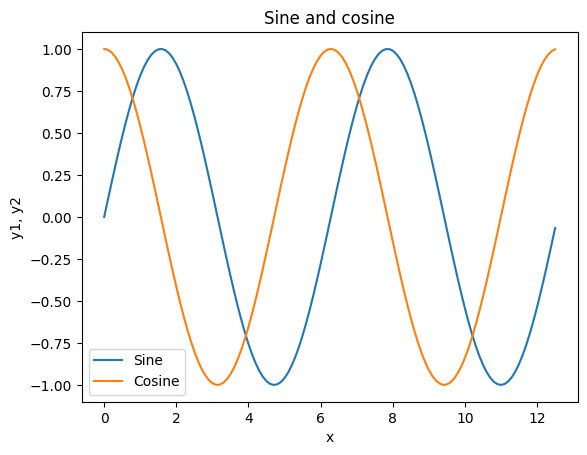

In [5]:
x = np.arange(0, 4*np.pi, 0.1)
y1 = np.sin(x)
y2 = np.cos(x)
plt.plot(x, y1)
plt.plot(x, y2)
plt.xlabel('x')
plt.ylabel('y1, y2')
plt.title('Sine and cosine')
plt.legend(['Sine', 'Cosine']) #In order of plots created.

Each curve is automatically plotted in a different color, but we can customize colors and even add a legend if we want.

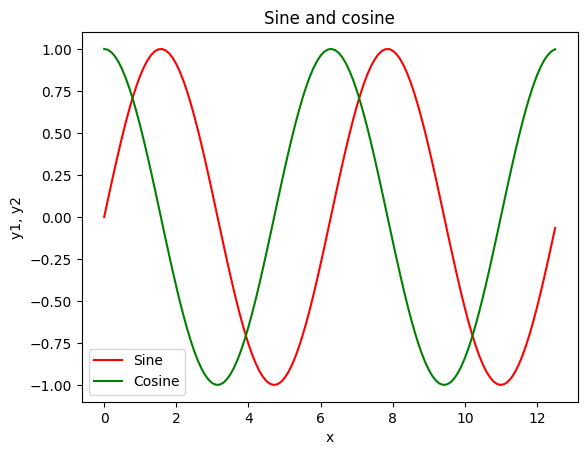

In [6]:
x = np.arange(0, 4*np.pi, 0.1)
y1 = np.sin(x)
y2 = np.cos(x)
plt.plot(x, y1, color='r')
plt.plot(x, y2, color='g')
plt.xlabel('x')
plt.ylabel('y1, y2')
plt.title('Sine and cosine')
plt.legend(['Sine', 'Cosine'])

Matplotlib offers many, many ways to customize your plots. Take a look at lots and lots of examples here: https://matplotlib.org/2.0.2/gallery.html

## Histograms

A histogram allows us to see how data is distributed, with the height of each bar showing how many of the data points fall within each "bin". Let's generate an array of random numbers from a uniform distribution and check that we get about the same number of counts in each bin.

[0.91084182 0.28114309 0.05539715 ... 0.78276906 0.57442553 0.49936476]


Text(0, 0.5, 'count')

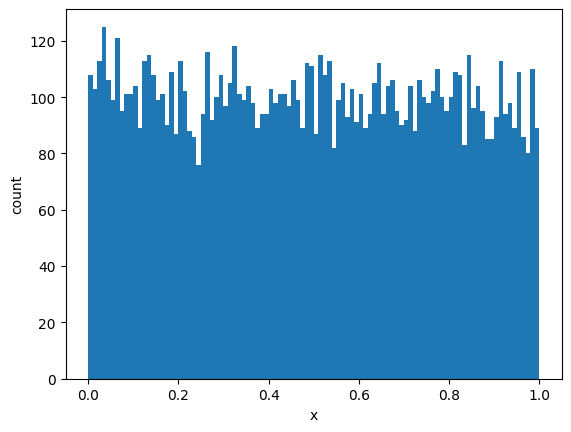

In [7]:
x = np.random.rand(10000) #creates a 1-D NumPy array of 10,000 random floating-point numbers uniformly distributed between 0 (inclusive) and 1 (exclusive).
print(x)
plt.hist(x, bins=100)
plt.xlabel('x')
plt.ylabel('count')

## Visualizing matrices

A common way to visualize two-dimensional data is as a color-coded matrix, also known as a heat map. This can be done using `plt.imshow`.

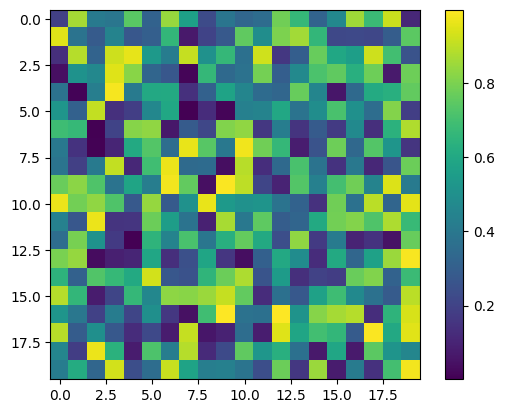

In [8]:
x = np.random.rand(20, 20) #Creates a 2-d arrays of of 20 x 20 random floating point numbers uniformly distributed between 0 (inclusive) - 20 (exclusive)
plt.imshow(x) #image-show, plot matrices.
plt.colorbar()  # This creates the color bar on the right hand side so we know what the colors mean

## Subplots

We can make subplots within the same plot. In the following examples, we'll illustrate two different distributions of random numbers in two different subplots. We'll also increase the number of bins in the histogram plots to show the distributions in more detail.

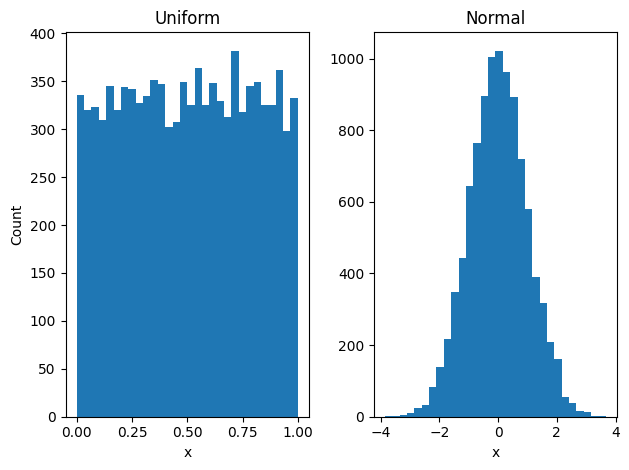

In [9]:
# Generate some random data:
x1 = np.random.rand(10000)
x2 = np.random.randn(10000)

# The first subplot:
plt.subplot(1,2,1) # the three numbers refer to the number of rows, number of columns, and which subplot we're making
plt.hist(x1, bins=30)
plt.title('Uniform')
plt.xlabel('x')
plt.ylabel('Count')

# The second subplot:
plt.subplot(1,2,2)
plt.hist(x2, bins=30)
plt.title('Normal')
plt.xlabel('x')

# Pro tip: The following line makes everything fit together more nicely.
# Try uncommenting it and compare the difference:
plt.tight_layout()

## Error bars

When we are working with actual data, we will often want to average it (e.g. averaging over trials in a neuroscience experiment) and include error bars to illustrate how spread out the data is. Let's create some fake data in which the underlying signal is a sine wave, and each trial has noise added to it. Then we'll plot the trial-averaged data together with error bars used to denote the standard deviation. This example will also include some of what we've learned about using for loops and performing operations over arrays.

Text(0, 0.5, 'y')

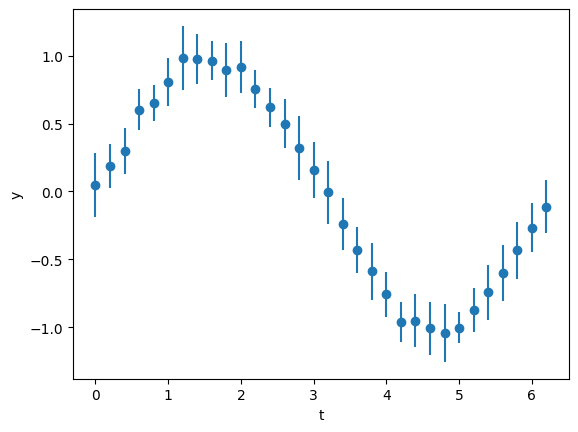

In [10]:
# Generate some fake data:
t = np.arange(0, 2*np.pi, 0.2) # Creates an array of time points from 0 to 2*pi with a step of 0.2
signal = np.sin(t) # Creates a signal that is a sine wave evaluated at the time points in t
n_timesteps = len(t) # Computes the number of time steps by taking the length of the array t
n_trials = 20 # Sets the number of trials to 20
y = np.zeros((n_trials, n_timesteps)) # Creates a 2D array of zeros with dimensions (n_trials, n_timesteps) to hold the noisy signals for each trial

# Add noise to the signal:
for i in range(n_trials):
    y[i,:] = signal + 0.2*np.random.randn(n_timesteps) # For each trial, adds random noise to the signal by generating a random array of the same length as t, scaling it by 0.2, and adding it to the original signal. The resulting noisy signal is stored in the corresponding row of the array y.

# Compute the mean and standard deviation over trials:
y_mean = np.mean(y, axis=0)
y_std = np.std(y, axis=0)

# Make the plot:
plt.errorbar(t, y_mean, yerr=y_std, fmt='o')
plt.xlabel('t')
plt.ylabel('y')